<a href="https://colab.research.google.com/github/AsmitaKabra/Tensorflow/blob/main/01_neural_network_regression_with_tf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
#Import Tensorflow
import tensorflow as tf
print(tf.__version__)

2.20.0


#### Creating data to view and fit

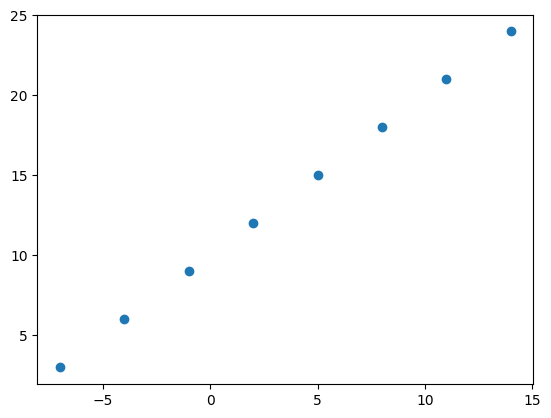

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Create features
X = np.array([-7.0,-4.0,-1.0,2.0,5.0,8.0,11.0,14.0])

#Create labels
y = np.array([3.0,6.0,9.0,12.0,15.0,18.0,21.0,24.0])

#visualize it
plt.scatter(X,y)

In [57]:
#Example of input and output shapes of regression model
house_info = tf.constant(['bedroom','bathroom','garage'])
house_price = tf.constant([939700])
house_info,house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [58]:
house_info.shape

TensorShape([3])

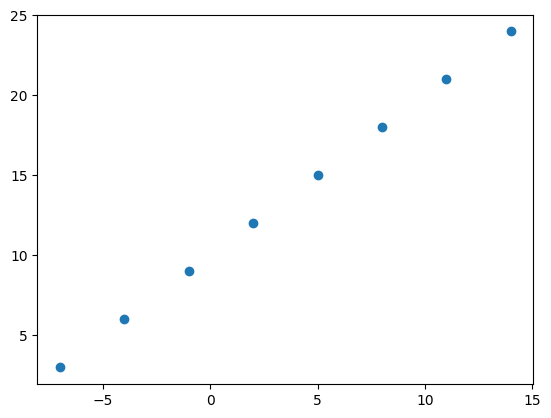

In [59]:
import numpy as np
import matplotlib.pyplot as plt

#Create features (using tensors)
X = tf.constant([-7.0,-4.0,-1.0,2.0,5.0,8.0,11.0,14.0])

#Create labels(using tensors)
y = tf.constant([3.0,6.0,9.0,12.0,15.0,18.0,21.0,24.0])

#Visualize it
plt.scatter(X,y);

In [60]:
#Take a single example of X
input_shape = X[0].shape

#Take single example of y
output_shape = y[0].shape

input_shape,output_shape #these are both scalars(no. shape)

(TensorShape([]), TensorShape([]))

###**Steps in modelling with TensorFlow**
Now we know what data we have as well as the input and output shapes, let's see how we'd build a neural network to model it.

In TensorFlow, there are typically 3 fundamental steps to creating and training a model.

1. **Creating a model** - piece together the layers of a neural network yourself (using the Functional or Sequential API) or import a previously built model (known as transfer learning).
2. **Compiling a model** - defining how a models performance should be measured (loss/metrics) as well as defining how it should improve (optimizer).
3. **Fitting a model** - letting the model try to find patterns in the data (how does X get to y).
Let's see these in action using the Keras Sequential API to build a model for our regression data. And then we'll step through each.

**Note**: If you're using TensorFlow 2.7.0+, the fit() function no longer upscales input data to go from (batch_size, ) to (batch_size, 1). To fix this, you'll need to expand the dimension of input data using tf.expand_dims(input_data, axis=-1).

In our case, this means instead of using model.fit(X, y, epochs=5), use model.fit(tf.expand_dims(X, axis=-1), y, epochs=5).

In [61]:
# Set random seed
tf.random.set_seed(42)

#Create a model using sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ['mae'])

#fit the model
model.fit(tf.expand_dims(X,axis=-1),y,epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - loss: 18.8366 - mae: 18.8366
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 18.5554 - mae: 18.5554
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 18.2741 - mae: 18.2741
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 17.9929 - mae: 17.9929
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 17.7116 - mae: 17.7116


In [62]:
#Check out X and y
X,y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [63]:
import numpy as np

model.predict(np.array([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[-15.209063]], dtype=float32)

### **Improving a model**
How do you think you'd improve upon our current model?

If you guessed by tweaking some of the things we did above, you'd be correct.

To improve our model, we alter almost every part of the 3 steps we went through before.

1. Creating a model - here you might want to add more layers, increase the number of hidden units (also called neurons) within each layer, change the activation functions of each layer.
2. Compiling a model - you might want to choose optimization function or perhaps change the learning rate of the optimization function.
3. Fitting a model - perhaps you could fit a model for more epochs (leave it training for longer) or on more data (give the model more examples to learn from).

In [64]:
# Set random seed
tf.random.set_seed(42)

# Create a model (same as above)
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile model (same as above)
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# Fit model (this time we'll train for longer)
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100) # train for 100 epochs not 10

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - loss: 18.9524 - mae: 18.9524
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 18.6712 - mae: 18.6712
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 18.3899 - mae: 18.3899
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 18.1087 - mae: 18.1087
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 17.8274 - mae: 17.8274
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 17.5462 - mae: 17.5462
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 17.2649 - mae: 17.2649
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 16.9837 - mae: 16.9837
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 16.7024 - mae: 16.7024
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 16.4212 - mae: 16.4212
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 16.1399 - mae: 16.1399
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 15.8587 - mae: 15.8587
Epoch 13/100
1/1 ━━━━━━━

In [65]:
#Remind ourselves oof what X and y are
X,y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [66]:
# Try and predict what y would be if X was 17.0
model.predict(np.array([17.0]))# the right answer is 27.0 (y = X + 10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


array([[29.306005]], dtype=float32)

### Evaluating a model
A typical workflow you'll go through when building neural networks is:

> Build a model -> evaluate it -> build (tweak) a model -> evaulate it -> build (tweak) a model -> evaluate it...

The tweaking comes from maybe not building a model from scratch but adjusting an existing one.

Visualize, visualize, visualize
When it comes to evaluation, you'll want to remember the words: "visualize, visualize, visualize."

This is because you're probably better looking at something (doing) than you are thinking about something.

It's a good idea to visualize:

* **The data** - what data are you working with? What does it look like?
* **The model itself** - what does the
architecture look like? What are the different shapes?
* **The training of a model** - how does a model perform while it learns?
The predictions of a model - how do the predictions of a model line up against the ground truth (the original labels)?
Let's start by visualizing the model.

But first, we'll create a little bit of a bigger dataset and a new model we can use (it'll be the same as before, but the more practice the better).

In [67]:
#make a bigger dataset
X = np.arange(-100,100,4)
X

array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])

In [68]:
#Make labels for dataset(adhering to the same pattern as before)
y = np.arange(-90,110,4)
y

array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

In [69]:
#Same result As above
#Since y = X + 10 , we could make the labels like so:
y = X+10
y

array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

### Split data into training / test set
One of the other most common and important steps in a machine learning project is creating a training and test set (and when required, a validation set).

Each set serves a specific purpose:

* **Training set** - the model learns from this data, which is typically 70-80% of the total data available (like the course materials you study during the semester).
* **Validation set** - the model gets tuned on this data, which is typically 10-15% of the total data available (like the practice exam you take before the final exam).
* **Test set** - the model gets evaluated on this data to test what it has learned, it's typically 10-15% of the total data available (like the final exam you take at the end of the semester).
For now, we'll just use a training and test set, this means we'll have a dataset for our model to learn on as well as be evaluated on.

We can create them by splitting our X and y arrays.

> 🔑 Note: When dealing with real-world data, this step is typically done right at the start of a project (the test set should always be kept separate from all other data). We want our model to learn on training data and then evaluate it on test data to get an indication of how well it generalizes to unseen examples.

In [70]:
#Check how many samples we have
len(X)

50

In [71]:
#Split data into train and test sets
X_train = X[:40]#first 40 examples(80% of data)
y_train = y[:40]
X_test = X[40:]
Y_test = y[40:]
len(X_train),len(X_test)

(40, 10)

### Visualizing the data
Now we've got our training and test data, it's a good idea to visualize it.

Let's plot it with some nice colours to differentiate what's what.

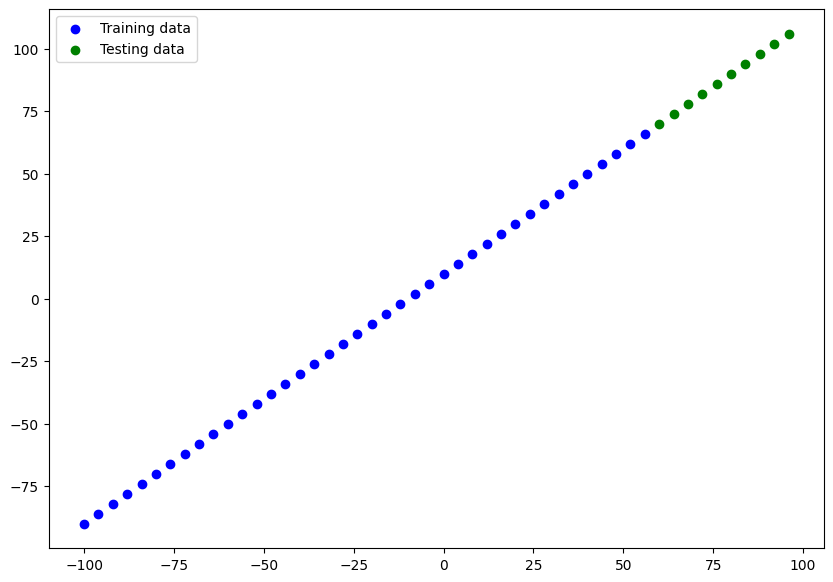

In [72]:
plt.figure(figsize = (10,7))
#Plot training data in blue
plt.scatter(X_train,y_train,c='b',label = 'Training data')
#Plot test data in green
plt.scatter(X_test,Y_test,c='g',label = 'Testing data')
#Show legend
plt.legend();

In [73]:
# tf.random.set_seed(42)
# #Create a model
# model = tf.keras.Sequential([
#     tf.keras.layers.Dense(1)
# ])
# #Compile model
# model.compile(loss = tf.keras.losses.mae,
#               optimizer = tf.keras.optimizers.SGD(),
#               metrics = ['mae'])
# #model.fit(X_train, y_train, epochs=100, verbose=0) # verbose controls how much gets output

In [74]:
#model.summary()

the cell above errors because we haven't fit or built our model.

We also haven't told it what input shape it should be expecting.

Remember above, how we discussed the input shape was just one number?

We can let our model know the input shape of our data using the input_shape parameter to the first layer (usually if input_shape isn't defined, Keras tries to figure it out automatically).

In [75]:
tf.random.set_seed(42)
#Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=[1])
])
#Compile model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ['mae'])
#model.fit(X_train, y_train, epochs=100, verbose=0) # verbose controls how much gets output

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Calling summary() on our model shows us the layers it contains, the output shape and the number of parameters.

* **Total params** - total number of parameters in the model.
* **Trainable parameters** - these are the parameters (patterns) the model can update as it trains.
* **Non-trainable parameters** - these parameters aren't updated during training (this is typical when you bring in the already learned patterns from other models during transfer learning).
> 📖 **Resource**: For a more in-depth overview of the trainable parameters within a layer, check out MIT's introduction to deep learning video.

> 🛠 **Exercise**: Try playing around with the number of hidden units in the Dense layer (e.g. Dense(2), Dense(3)). How does this change the Total/Trainable params? Investigate what's causing the change.

For now, all you need to think about these parameters is that their learnable patterns in the data.

Let's fit our model to the training data.

In [77]:
#Fit the model to the training data
model.fit(X_train, y_train, epochs=100, verbose=0) # verbose controls how much gets output

In [78]:
#Check model summary
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Alongside summary, you can also view a 2D plot of the model using plot_model().

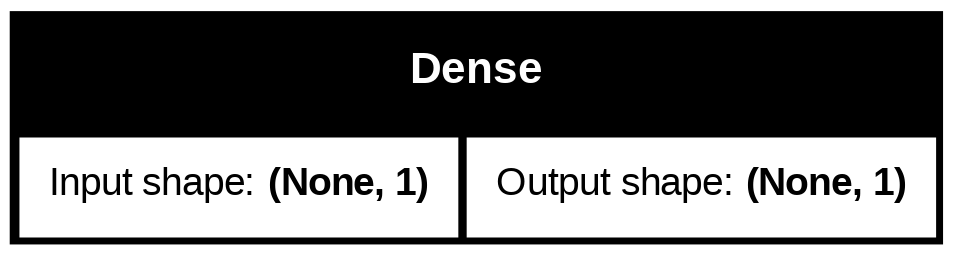

In [79]:
from tensorflow.keras.utils import plot_model
plot_model(model,show_shapes = True)

In our case, the model we used only has an input and an output but visualizing more complicated models can be very helpful for debugging.

## Visualizing the predictions
Now we've got a trained model, let's visualize some predictions.

To visualize predictions, it's always a good idea to plot them against the ground truth labels.

Often you'll see this in the form of y_test vs. y_pred (ground truth vs. predictions).

First, we'll make some predictions on the test data (X_test), remember the model has never seen the test data.

In [80]:
#Make predictions

y_preds = model.predict(tf.expand_dims(X_test, axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [81]:
y_preds

array([[ 68.69706 ],
       [ 73.18282 ],
       [ 77.66859 ],
       [ 82.15435 ],
       [ 86.640114],
       [ 91.12588 ],
       [ 95.61163 ],
       [100.0974  ],
       [104.58316 ],
       [109.068924]], dtype=float32)

Okay, we get a list of numbers but how do these compare to the ground truth labels?

Let's build a plotting function to find out.

🔑 **Note**: If you think you're going to be visualizing something a lot, it's a good idea to functionize it so you can use it later.

In [82]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = Y_test,
                     predictions=y_preds):
  '''Plot training data , test data and compares predictions'''
  plt.figure(figsize=(10,7))
  #plot training data in blue
  plt.scatter(train_data,train_labels,c="b",label = "Training data")
  #Plot test data in green
  plt.scatter(test_data , test_labels , c = "g",label = "Testing data")
  #plot predictions in red(predictions were made in test data)
  plt.scatter(test_data,predictions,c="r",label = "Predictions")
  #Show the legend
  plt.legend();

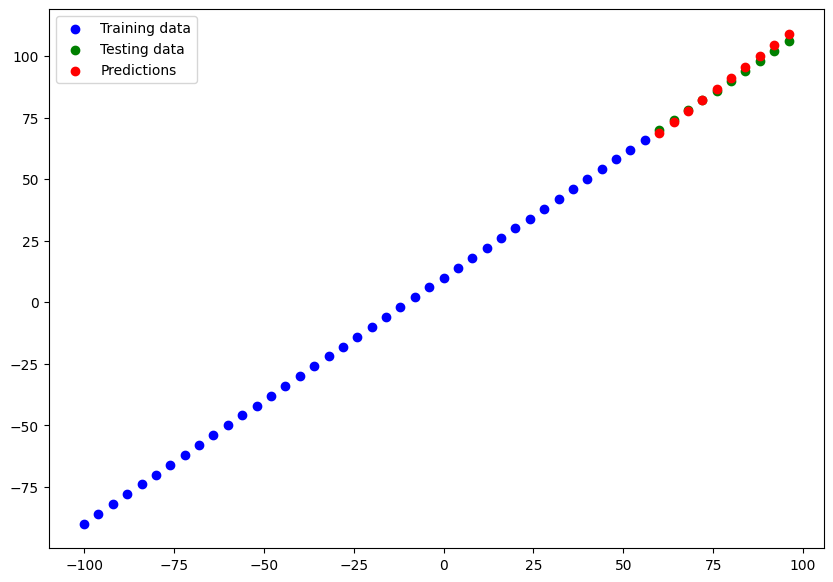

In [83]:
plot_predictions(train_data=X_train,
                 train_labels = y_train,
                 test_data=X_test,
                 test_labels=Y_test,
                 predictions = y_preds)

### Evaluating predictions

In [110]:
# Evaluate the model on the test set
model.evaluate(X_test, Y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 1.3733 - mae: 1.3733


[1.3732986450195312, 1.3732986450195312]

In [108]:
tf.keras.losses.MAE(
        y_true=Y_test,
        y_pred=y_preds
    )

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([1.3029404 , 0.8171768 , 0.33141327, 0.15435028, 0.64011383,
       1.1258774 , 1.6116333 , 2.0973969 , 2.5831604 , 3.068924  ],
      dtype=float32)>

Huh? That's strange, MAE should be a single output.

Instead, we get 10 values.

This is because our y_test and y_preds tensors are different shapes.

In [86]:
#Check test label tensor values
Y_test

array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

In [87]:
# Check the predictions tensor values (notice the extra square brackets)
y_preds

array([[ 68.69706 ],
       [ 73.18282 ],
       [ 77.66859 ],
       [ 82.15435 ],
       [ 86.640114],
       [ 91.12588 ],
       [ 95.61163 ],
       [100.0974  ],
       [104.58316 ],
       [109.068924]], dtype=float32)

In [88]:
# Check the tensor shapes
Y_test.shape,y_preds.shape

((10,), (10, 1))

Remember how we discussed dealing with different input and output shapes is one the most common issues you'll come across, this is one of those times.

But not to worry.

We can fix it using squeeze(), it'll remove the the 1 dimension from our y_preds tensor, making it the same shape as y_test.

🔑 Note: If you're comparing two tensors, it's important to make sure they're the right shape(s) (you won't always have to manipulate the shapes, but always be on the look out, many errors are the result of mismatched tensors, especially mismatched input and output shapes).

In [89]:
y_preds.squeeze().shape

(10,)

In [90]:
# What do they look like?
Y_test,y_preds.squeeze()

(array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106]),
 array([ 68.69706 ,  73.18282 ,  77.66859 ,  82.15435 ,  86.640114,
         91.12588 ,  95.61163 , 100.0974  , 104.58316 , 109.068924],
       dtype=float32))

In [91]:
# Calculate the mean absolute error
mae = tf.keras.losses.MAE(y_true=Y_test,
                                     y_pred=y_preds.squeeze())
mae

<tf.Tensor: shape=(), dtype=float32, numpy=1.3732986450195312>

In [92]:
# Returns the same as tf.metrics.mean_absolute_error()
tf.reduce_mean(tf.abs(Y_test-y_preds.squeeze()))

<tf.Tensor: shape=(), dtype=float64, numpy=1.3732986450195312>

In [93]:
def mae(y_test, y_pred):
    return tf.keras.losses.MAE(
        y_true=y_test,
        y_pred=y_pred.squeeze()
    )

def mse(y_test, y_pred):
    return tf.keras.losses.MSE(
        y_true=y_test,
        y_pred=y_pred.squeeze()
    )

## Running experiments to improve a model
After seeing the evaluation metrics and the predictions your model makes, it's likely you'll want to improve it.

Again, there are many different ways you can do this, but 3 of the main ones are:

* **Get more data** - get more examples for your model to train on (more opportunities to learn patterns).
* **Make your model larger (use a more complex model)** - this might come in the form of more layers or more hidden units in each layer.
* **Train for longer** - give your model more of a chance to find the patterns in the data.
Since we created our dataset, we could easily make more data but this isn't always the case when you're working with real-world datasets.

So let's take a look at how we can improve our model using 2 and 3.

To do so, we'll build 3 models and compare their results:

1. model_1 - same as original model, 1 layer, trained for 100 epochs.
2. model_2 - 2 layers, trained for 100 epochs.
3. model_3 - 2 layers, trained for 500 epochs.
Build model_1

### **Build Model_1**

In [94]:
# Set random seed
tf.random.set_seed(42)

# Replicate original model
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_1.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 109.2724 - mae: 109.2724 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 74.4969 - mae: 74.4969
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 39.8382 - mae: 39.8382
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 10.5794 - mae: 10.5794
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 8.2086 - mae: 8.2086
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9.8871 - mae: 9.8871
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 8.1899 - mae: 8.1899
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 9.8742 - mae: 9.8742
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.1712 - mae: 8.1712
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 9.8612 - mae: 9.8612
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 8.1525 - mae: 8.1525
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9.8483 - mae: 9.8483
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


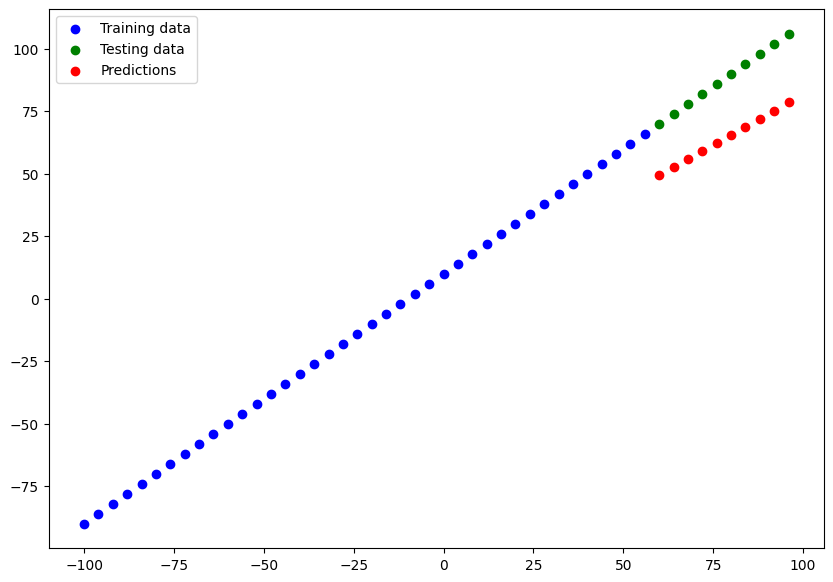

In [95]:
# Make and plot predictions for model_1
# y_preds_1 = model_1.predict(X_test)

y_preds_1 = model_1.predict(tf.expand_dims(X_test, axis=-1))
plot_predictions(predictions=y_preds_1)

In [96]:
# Calculate model_1 metrics
mae_1 = mae(Y_test, y_preds_1).numpy()
mse_1 = mse(Y_test, y_preds_1).numpy()
mae_1, mse_1

(np.float32(23.940659), np.float32(578.24316))

### **Build model_2**
This time we'll add an extra dense layer (so now our model will have 2 layers) whilst keeping everything else the same.

In [97]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_1 and add an extra layer
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1) # add a second layer
])

# Compile the model
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_2.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100, verbose=0) # set verbose to 0 for less output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


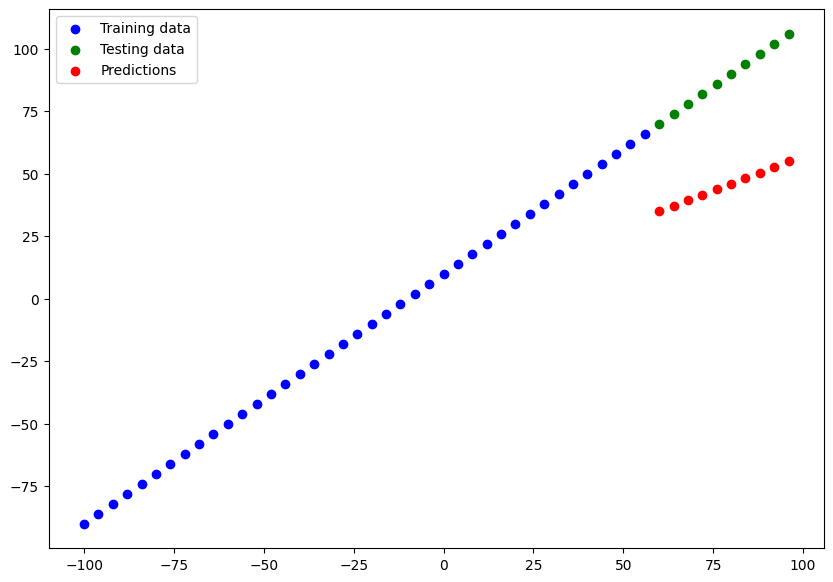

In [98]:
# Make and plot predictions for model_2
#y_preds_2 = model_2.predict(X_test)

y_preds_2 = model_2.predict(tf.expand_dims(X_test, axis=-1))
plot_predictions(predictions=y_preds_2)

In [99]:
# Calculate model_2 metrics
mae_2 = mae(Y_test, y_preds_2).numpy()
mse_2 = mse(Y_test, y_preds_2).numpy()
mae_2, mse_2

(np.float32(43.07325), np.float32(1881.3541))

### **Build model_3**
For our 3rd model, we'll keep everything the same as model_2 except this time we'll train for longer (500 epochs instead of 100).

This will give our model more of a chance to learn the patterns in the data.

In [100]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_2
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model (this time for 500 epochs, not 100)
model_3.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0) # set verbose to 0 for less output


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


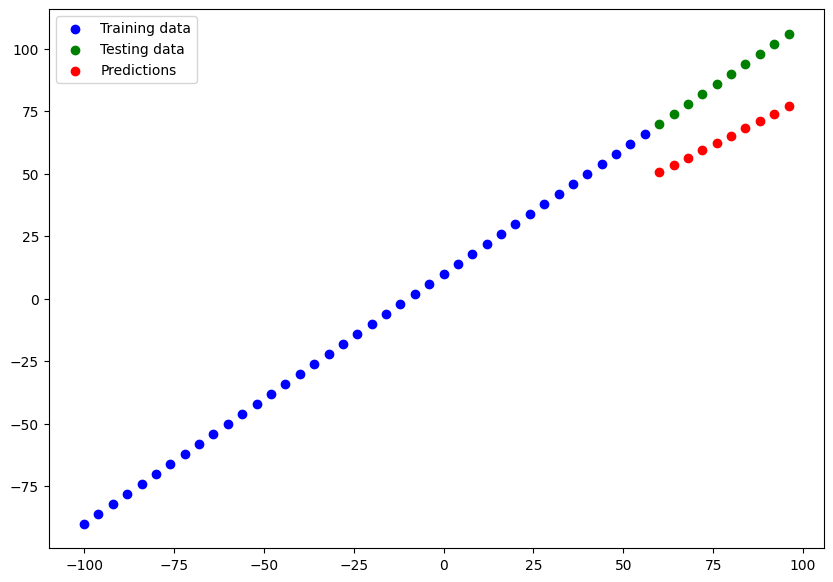

In [101]:
# Make and plot predictions for model_3
#y_preds_3 = model_3.predict(X_test)
# Cell 65
y_preds_3 = model_3.predict(tf.expand_dims(X_test, axis=-1))
plot_predictions(predictions=y_preds_3)

In [102]:
# Calculate model_3 metrics
mae_3 = mae(Y_test, y_preds_3).numpy()
mse_3 = mse(Y_test, y_preds_3).numpy()
mae_3, mse_3


(np.float32(24.177553), np.float32(593.9595))

In [103]:
model_results = [
    ["model_1", mae_1, mse_1],
    ["model_2", mae_2, mse_2],
    ["model_3", mae_3, mse_3]
]

In [104]:
import pandas as pd
all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_1,23.940659,578.243164
1,model_2,43.073250,1881.354126
2,model_3,24.177553,593.959473


### **Tracking your experiments**
One really good habit to get into is tracking your modelling experiments to see which perform better than others.

We've done a simple version of this above (keeping the results in different variables).

📖 Resource: But as you build more models, you'll want to look into using tools such as:

TensorBoard - a component of the TensorFlow library to help track modelling experiments (we'll see this later).

Weights & Biases - a tool for tracking all kinds of machine learning experiments (the good news for Weights & Biases is it plugs into TensorBoard).

### **Saving a model**
Once you've trained a model and found one which performs to your liking, you'll probably want to save it for use elsewhere (like a web application or mobile device).

You can save a TensorFlow/Keras model using model.save().

There are two ways to save a model in TensorFlow:

1. The SavedModel format (default).
2. The HDF5 format.

The main difference between the two is the SavedModel is automatically able to save custom objects (such as special layers) without additional modifications when loading the model back in.

Which one should you use?

It depends on your situation but the SavedModel format will suffice most of the time.

Both methods use the same method call.

In [112]:
# Save a model using the SavedModel format
model_1.save('best_model_SavedModel_format.keras')

In [114]:
!ls best_model_SavedModel_format.keras

best_model_SavedModel_format.keras


In [115]:
# Save a model using the HDF5 format
model_2.save("best_model_HDF5_format.h5") # note the addition of '.h5' on the end


In [116]:
!ls best_model_HDF5_format.h5

best_model_HDF5_format.h5


### **Loading a model**
We can load a saved model using the load_model() method.

Loading a model for the different formats (SavedModel and HDF5) is the same (as long as the pathnames to the particular formats are correct).

In [118]:
# Load a model from the SavedModel format
loaded_saved_model = tf.keras.models.load_model("best_model_SavedModel_format.keras")
loaded_saved_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [121]:
# Load a model from the HDF5 format
loaded_h5_model = tf.keras.models.load_model("best_model_HDF5_format.h5")
loaded_h5_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (28.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [123]:
# Compare model_2 with the loaded HDF5 version (should return True)
h5_model_preds = loaded_h5_model.predict(X_test)
mae(Y_test, h5_model_preds.squeeze()).numpy() == mae(Y_test, model_2_preds.squeeze()).numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


np.True_